# Fruit Image Classification with CNN
### Student ID: 2414174 | Name: Aayush Gurung
### Part A: CNN from Scratch | Part B: Transfer Learning


##  Step 1: Import

In [1]:
import os
import time
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  Step 2: Mount Drive & Extract Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_path     = '/content/drive/MyDrive/Fruit Classification-20260507T055432Z-3-001.zip'
extract_path = '/content/fruit_dataset'

if not os.path.exists(extract_path):
    print('Extracting...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print('Done!')
else:
    print('Already extracted.')

train_dir = '/content/fruit_dataset/Fruit Classification/Train'
test_dir  = '/content/fruit_dataset/Fruit Classification/Test'

print('Train dir exists:', os.path.exists(train_dir))
print('Test dir exists :', os.path.exists(test_dir))

Extracting...
Done!
Train dir exists: True
Test dir exists : True


In [4]:
# ── STEP 2b: Validate & Remove Corrupt Images ─────────────────────────────
import io
from PIL import Image as PILImage

def validate_and_clean(directory, verbose=True):
    """Walk directory, remove any file PIL cannot open."""
    removed = []
    for root, dirs, files in os.walk(directory):
        for fname in files:
            fpath = os.path.join(root, fname)
            try:
                with open(fpath, 'rb') as f:
                    img = PILImage.open(io.BytesIO(f.read()))
                    img.verify()          # checks file integrity without decoding
            except Exception as e:
                if verbose:
                    print(f'  ✗ Removing corrupt file: {fpath}  ({e})')
                os.remove(fpath)
                removed.append(fpath)
    return removed

print('Scanning Train folder for corrupt images...')
bad = validate_and_clean(train_dir)
print(f'Done — removed {len(bad)} corrupt file(s).\n')


Scanning Train folder for corrupt images...
  ✗ Removing corrupt file: /content/fruit_dataset/Fruit Classification/Train/Cherry/r_262_100(1).jpg  (cannot identify image file <_io.BytesIO object at 0x786d50598d60>)
  ✗ Removing corrupt file: /content/fruit_dataset/Fruit Classification/Train/Cherry/r_202_100.jpg  (cannot identify image file <_io.BytesIO object at 0x786d50598d60>)
  ✗ Removing corrupt file: /content/fruit_dataset/Fruit Classification/Train/Cherry/r_136_100(1).jpg  (cannot identify image file <_io.BytesIO object at 0x786d50599710>)
  ✗ Removing corrupt file: /content/fruit_dataset/Fruit Classification/Train/Cherry/r_269_100.jpg  (cannot identify image file <_io.BytesIO object at 0x786d50599710>)
  ✗ Removing corrupt file: /content/fruit_dataset/Fruit Classification/Train/Cherry/r_217_100.jpg  (cannot identify image file <_io.BytesIO object at 0x786d50599710>)
  ✗ Removing corrupt file: /content/fruit_dataset/Fruit Classification/Train/Cherry/r_302_100.jpg  (cannot identify

In [5]:
# ── STEP 3b: Strict Group-Based Split — fixes 1.0 accuracy data leakage ───
# Filename pattern: '104_100(1).jpg'
#   → '104' is the fruit number (same physical fruit)
#   → '_100', '(1)', '(2)' are just different angle/variation shots
# GroupShuffleSplit keeps ALL variants of fruit #104 in the SAME split.

import os, shutil, pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Delete old leaky dataset if it exists
for _old in ['/content/dataset', '/content/strict_dataset']:
    if os.path.exists(_old):
        shutil.rmtree(_old)
        print(f'Removed old dataset: {_old}')

base_dir = '/content/strict_dataset'

if not os.path.exists(base_dir):
    os.makedirs(base_dir, exist_ok=True)

    data = []
    for cls in os.listdir(train_dir):
        cls_path = os.path.join(train_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_name in os.listdir(cls_path):
            if not os.path.isfile(os.path.join(cls_path, img_name)):
                continue

            # ── KEY FIX: group by the fruit number (everything before first '_')
            # '0_100(2).jpg'   → group 'Banana_0'
            # '104_100(1).jpg' → group 'Banana_104'
            # '104_100.jpg'    → group 'Banana_104'  (same group!)
            fruit_number = img_name.split('_')[0]
            group_id     = f"{cls}_{fruit_number}"

            data.append({
                'filename' : img_name,
                'class'    : cls,
                'full_path': os.path.join(cls_path, img_name),
                'group'    : group_id
            })

    df = pd.DataFrame(data)
    print(f'Total images  : {len(df)}')
    print(f'Unique groups : {df["group"].nunique()}')
    print(f'Sample groups : {df["group"].unique()[:8].tolist()}')

    # ── Split 1: 70% train vs 30% temp ───────────────────────────────────────
    gss = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
    train_idx, temp_idx = next(gss.split(df, groups=df['group']))
    train_df = df.iloc[train_idx]
    temp_df  = df.iloc[temp_idx]

    # ── Split 2: 50/50 of temp → 15% val + 15% test ──────────────────────────
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
    val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['group']))
    val_df  = temp_df.iloc[val_idx]
    test_df = temp_df.iloc[test_idx]

    # ── Copy files ────────────────────────────────────────────────────────────
    def copy_files(subset_df, split_name):
        for _, row in subset_df.iterrows():
            dest = os.path.join(base_dir, split_name, row['class'])
            os.makedirs(dest, exist_ok=True)
            shutil.copy(row['full_path'], os.path.join(dest, row['filename']))

    print('Copying files...')
    copy_files(train_df, 'train')
    copy_files(val_df,   'validation')
    copy_files(test_df,  'test')

    # ── Verify ZERO group overlap ─────────────────────────────────────────────
    tv = set(train_df['group']) & set(val_df['group'])
    tt = set(train_df['group']) & set(test_df['group'])
    print(f'\nLeakage check:')
    print(f'  Train ∩ Val  : {len(tv)} groups  ← must be 0')
    print(f'  Train ∩ Test : {len(tt)} groups  ← must be 0')
    print(f'\nDone!  Train:{len(train_df)} | Val:{len(val_df)} | Test:{len(test_df)}')

else:
    print('Strict dataset already exists — skipping.')

# Update paths for all downstream cells
train_dir_split = os.path.join(base_dir, 'train')
val_dir_split   = os.path.join(base_dir, 'validation')
test_dir_split  = os.path.join(base_dir, 'test')

for label, d in [('Train', train_dir_split), ('Val', val_dir_split), ('Test', test_dir_split)]:
    total = sum(len(os.listdir(os.path.join(d, c)))
                for c in os.listdir(d) if os.path.isdir(os.path.join(d, c)))
    print(f'  {label}: {total} images')


Total images  : 6242
Unique groups : 1763
Sample groups : ['Cherry_r2', 'Cherry_311', 'Cherry_r', 'Cherry_114', 'Cherry_308', 'Cherry_140', 'Cherry_154', 'Cherry_257']
Copying files...

Leakage check:
  Train ∩ Val  : 0 groups  ← must be 0
  Train ∩ Test : 0 groups  ← must be 0

Done!  Train:4676 | Val:411 | Test:1155
  Train: 4676 images
  Val: 411 images
  Test: 1155 images


##  Step 3: Data Understanding & Visualization


In [6]:
# --- Class names from Train folder only (Test has no subfolders) ---
classes = sorted([
    c for c in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, c))
])
num_classes  = len(classes)
train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
total_images = sum(train_counts.values())

print(f'Number of classes : {num_classes}')
print(f'Classes           : {classes}')
print(f'Images per class  : {train_counts}')
print(f'Total images      : {total_images}')
print()
print('NOTE: Test folder contains only 5 unlabeled images — not usable for evaluation.')
print('We will split the Train folder into 70% train / 15% val / 15% test.')

Number of classes : 5
Classes           : ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']
Images per class  : {'Banana': 1422, 'Cherry': 1222, 'Grape': 1468, 'Mango': 908, 'Peach': 1222}
Total images      : 6242

NOTE: Test folder contains only 5 unlabeled images — not usable for evaluation.
We will split the Train folder into 70% train / 15% val / 15% test.


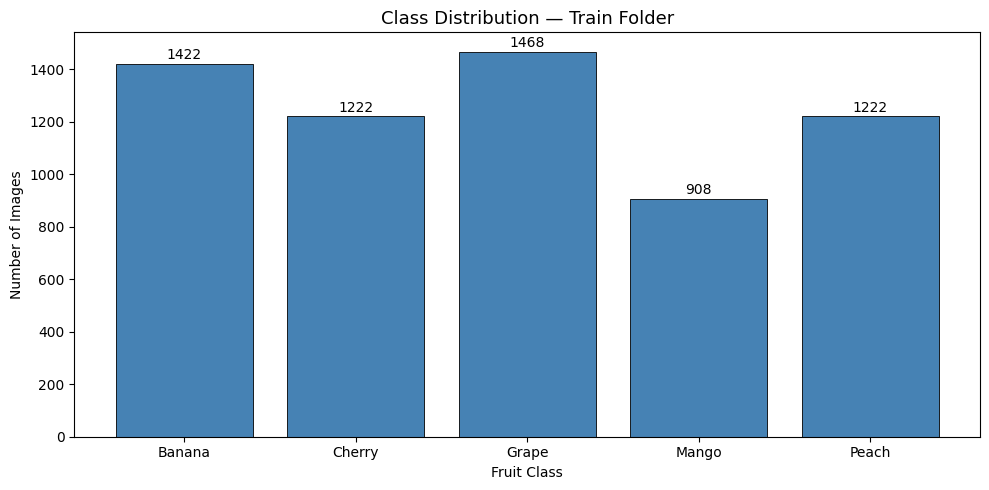

In [7]:
# --- Class distribution bar chart ---
plt.figure(figsize=(10, 5))
bars = plt.bar(train_counts.keys(), train_counts.values(),
               color='steelblue', edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, train_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=10)
plt.title('Class Distribution — Train Folder', fontsize=13)
plt.xlabel('Fruit Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150)
plt.show()

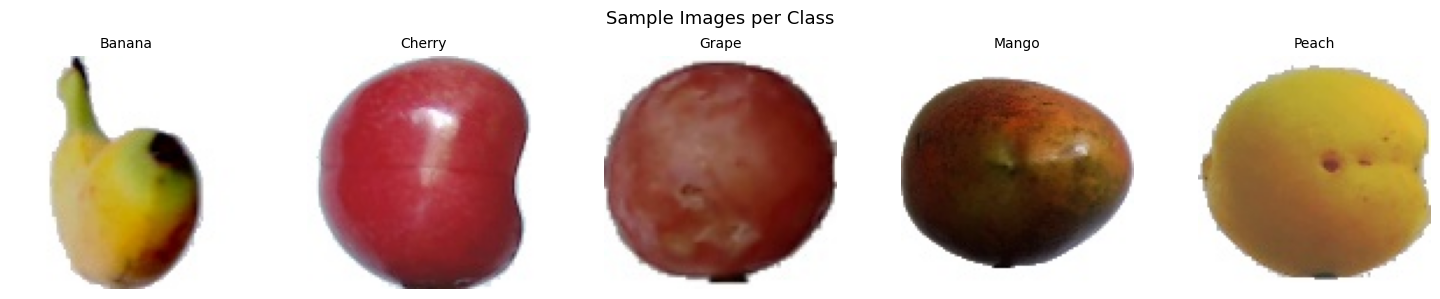

In [8]:
# --- Sample images: 1 per class ---
cols = min(num_classes, 5)
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if num_classes > 1 else [axes]

for i, cls in enumerate(classes):
    folder    = os.path.join(train_dir, cls)
    img_file  = os.listdir(folder)[0]
    img       = mpimg.imread(os.path.join(folder, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images per Class', fontsize=13)
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150)
plt.show()

##  Step 4: Preprocessing & Data Generators
**Split strategy:** Original Train folder → 70 % train / 15 % validation / 15 % test  


In [9]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
SEED       = 42

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.15, zoom_range=0.2,
    horizontal_flip=True
)
eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir_split, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_generator = eval_datagen.flow_from_directory(
    val_dir_split, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=SEED
)
test_generator = eval_datagen.flow_from_directory(
    test_dir_split, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=SEED
)
print(f'Train:{train_generator.samples} | Val:{val_generator.samples} | Test:{test_generator.samples}')
print(f'Classes: {list(train_generator.class_indices.keys())}')


Found 4676 images belonging to 5 classes.
Found 411 images belonging to 5 classes.
Found 1155 images belonging to 5 classes.
Train:4676 | Val:411 | Test:1155
Classes: ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']


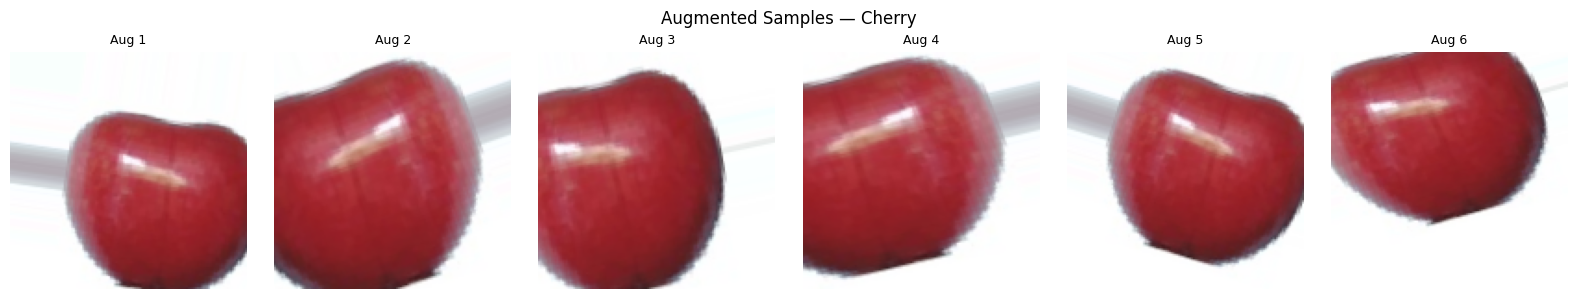

In [10]:
# Visualize augmented images from the SPLIT train folder
from tensorflow.keras.preprocessing.image import img_to_array, load_img

aug_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, zoom_range=0.2, horizontal_flip=True
)
sample_cls    = os.listdir(train_dir_split)[0]
sample_folder = os.path.join(train_dir_split, sample_cls)
sample_file   = [f for f in os.listdir(sample_folder)
                 if os.path.isfile(os.path.join(sample_folder, f))][0]
sample_img    = load_img(os.path.join(sample_folder, sample_file), target_size=IMG_SIZE)
sample_arr    = np.expand_dims(img_to_array(sample_img), 0)
aug_iter      = aug_gen.flow(sample_arr, batch_size=1)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(next(aug_iter)[0]); ax.set_title(f'Aug {i+1}', fontsize=9); ax.axis('off')
plt.suptitle(f'Augmented Samples — {sample_cls}', fontsize=12)
plt.tight_layout()
plt.savefig('/content/augmented_samples.png', dpi=150)
plt.show()


Baseline CNN Model

In [11]:
def build_baseline_model(num_classes):
    model = models.Sequential(name='Baseline_CNN')
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(128,128,3)))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64,  activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

baseline_model = build_baseline_model(num_classes)
baseline_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/baseline_best.keras',
                    save_best_only=True, monitor='val_accuracy', verbose=1)
]

t0 = time.time()
baseline_history = baseline_model.fit(
    train_generator,
    epochs          = 30,
    validation_data = val_generator,
    callbacks       = callbacks_baseline,
    verbose         = 1
)
baseline_time = time.time() - t0
print(f'\nBaseline training time: {baseline_time:.1f}s')

Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4667 - loss: 1.2344
Epoch 1: val_accuracy improved from None to 0.88564, saving model to /content/baseline_best.keras

Epoch 1: finished saving model to /content/baseline_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.6580 - loss: 0.8287 - val_accuracy: 0.8856 - val_loss: 0.2913
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9079 - loss: 0.2566
Epoch 2: val_accuracy improved from 0.88564 to 0.94161, saving model to /content/baseline_best.keras

Epoch 2: finished saving model to /content/baseline_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - accuracy: 0.9335 - loss: 0.1870 - val_accuracy: 0.9416 - val_loss: 0.1703
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9624 - loss: 0.1261
Epoch 3: val_accuracy improved from 0.94161 to 1.00000, saving model to /content/baseline_best.keras

Epoch 3: finished saving model to /content/baseline_best.keras
147/

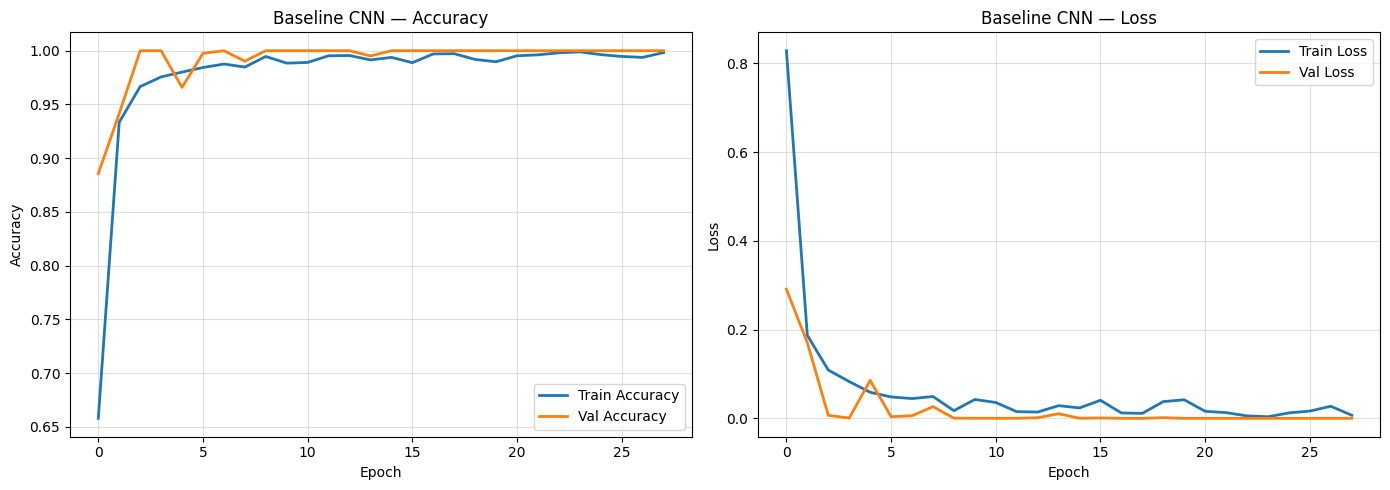

In [13]:
# --- Reusable plot function ---
def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, val_metric, ylabel in zip(
        axes,
        ['accuracy', 'loss'],
        ['val_accuracy', 'val_loss'],
        ['Accuracy', 'Loss']
    ):
        ax.plot(history.history[metric],     label=f'Train {ylabel}', linewidth=2)
        ax.plot(history.history[val_metric], label=f'Val {ylabel}',   linewidth=2)
        ax.set_title(f'{title} — {ylabel}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'/content/{title.replace(" ","_")}_curves.png', dpi=150)
    plt.show()

plot_history(baseline_history, 'Baseline CNN')


Baseline CNN
  Test Loss     : 0.0006
  Test Accuracy : 1.0000

Classification Report — Baseline CNN
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       105
      Cherry       1.00      1.00      1.00       327
       Grape       1.00      1.00      1.00        95
       Mango       1.00      1.00      1.00        67
       Peach       1.00      1.00      1.00       561

    accuracy                           1.00      1155
   macro avg       1.00      1.00      1.00      1155
weighted avg       1.00      1.00      1.00      1155



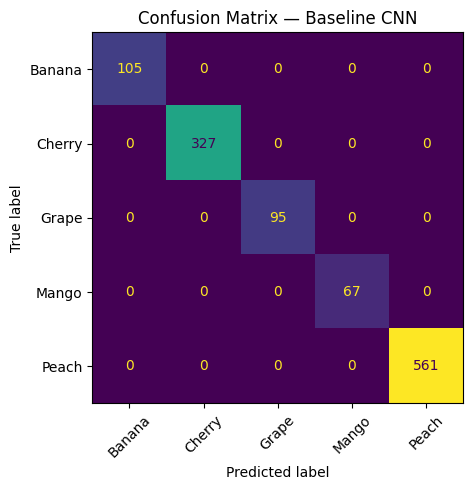

In [14]:
# --- Reusable evaluation function ---
def evaluate_model(model, generator, class_names, title='Model'):
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)
    print(f'\n{title}')
    print(f'  Test Loss     : {loss:.4f}')
    print(f'  Test Accuracy : {acc:.4f}')

    generator.reset()
    y_pred = np.argmax(model.predict(generator, verbose=0), axis=1)
    y_true = generator.classes

    print(f'\nClassification Report — {title}')
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm   = confusion_matrix(y_true, y_pred)
    size = max(6, num_classes)
    fig, ax = plt.subplots(figsize=(size, size - 1))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f'Confusion Matrix — {title}')
    plt.tight_layout()
    plt.savefig(f'/content/{title.replace(" ","_")}_confusion.png', dpi=150)
    plt.show()

    return loss, acc, y_pred, y_true

b_loss, b_acc, b_pred, b_true = evaluate_model(
    baseline_model, test_generator, classes, 'Baseline CNN'
)

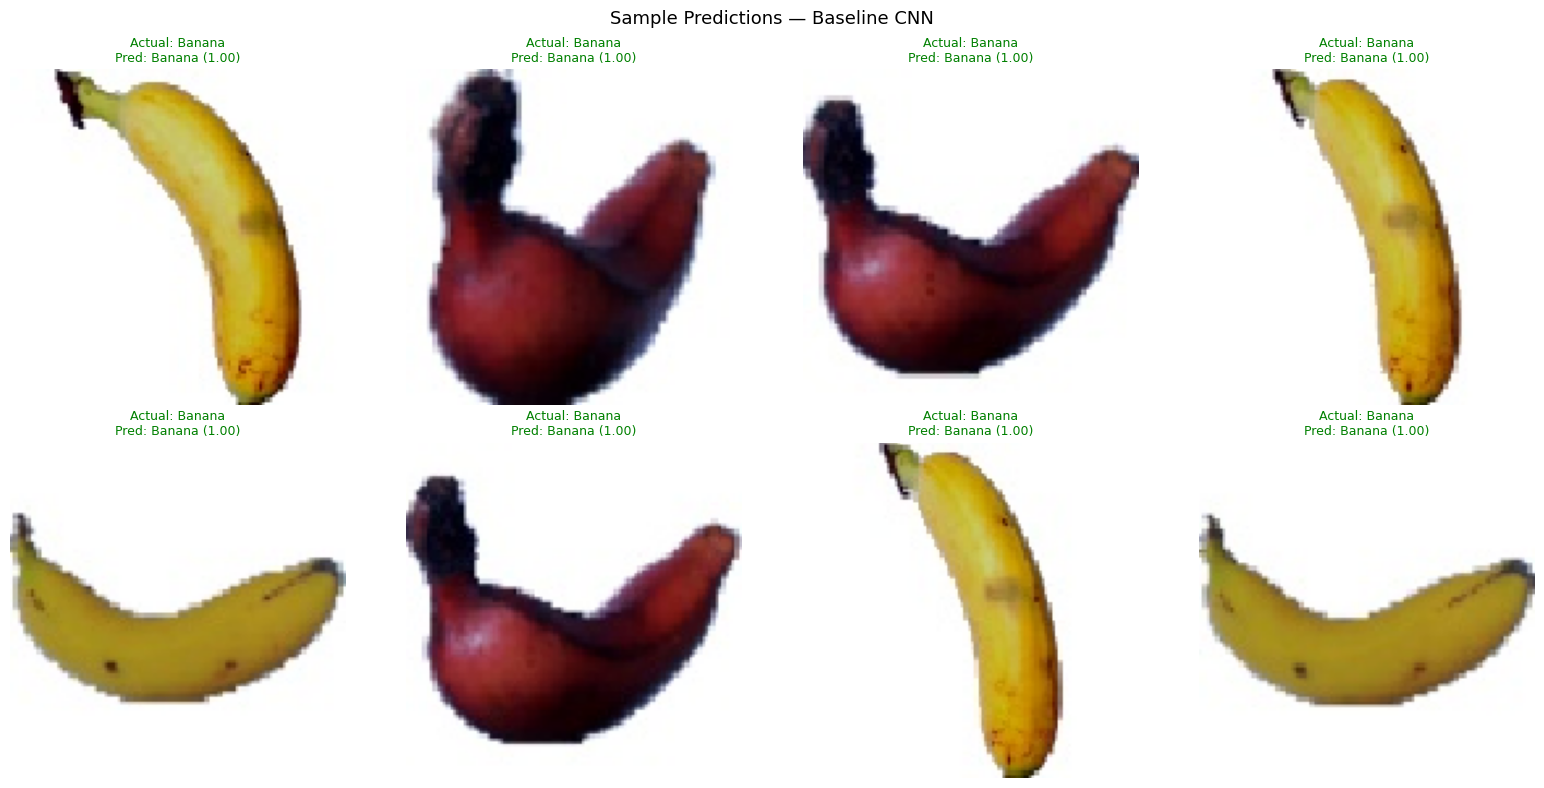

In [15]:
# --- Inference on sample images ---
def show_predictions(model, generator, class_names, n=8, title='Model'):
    generator.reset()
    images, labels = next(generator)
    n      = min(n, len(images))
    probs  = model.predict(images[:n], verbose=0)   # shape: (n, num_classes)
    preds  = np.argmax(probs, axis=1)
    confs  = np.max(probs, axis=1)                  # confidence score per prediction
    truths = np.argmax(labels[:n], axis=1)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flatten()):
        if i < n:
            ax.imshow(images[i])
            color = 'green' if preds[i] == truths[i] else 'red'
            ax.set_title(
                f'Actual: {class_names[truths[i]]}\n'
                f'Pred: {class_names[preds[i]]} ({confs[i]:.2f})',
                color=color, fontsize=9
            )
        ax.axis('off')

    plt.suptitle(f'Sample Predictions — {title}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'/content/{title.replace(" ","_")}_predictions.png', dpi=150)
    plt.show()

show_predictions(baseline_model, test_generator, classes, title='Baseline CNN')


##  Deeper CNN with Regularization

In [16]:
def build_deeper_model(num_classes):
    model = models.Sequential(name='Deeper_CNN')

    # Block 1
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=(128, 128, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))

    # Block 4
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))

    # Block 5
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))

    # Block 6
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.40))

    # Fully connected
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.40))

    # Output
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

deeper_model = build_deeper_model(num_classes)
deeper_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,475,365 (28.52 MB)

 Trainable params: 7,471,333 (28.50 MB)

 Non-trainable params: 4,032 (15.75 KB)

In [17]:
callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/deeper_best.keras',
                    save_best_only=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

t0 = time.time()
deeper_history = deeper_model.fit(
    train_generator,
    epochs          = 40,
    validation_data = val_generator,
    callbacks       = callbacks_deeper,
    verbose         = 1
)
deeper_time = time.time() - t0
print(f'\nDeeper model training time: {deeper_time:.1f}s')

Epoch 1/40
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.6795 - loss: 1.0200
Epoch 1: val_accuracy improved from None to 0.18735, saving model to /content/deeper_best.keras

Epoch 1: finished saving model to /content/deeper_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 77s 343ms/step - accuracy: 0.7977 - loss: 0.6376 - val_accuracy: 0.1873 - val_loss: 31.0680 - learning_rate: 0.0010
Epoch 2/40
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9131 - loss: 0.2867
Epoch 2: val_accuracy improved from 0.18735 to 0.36253, saving model to /content/deeper_best.keras

Epoch 2: finished saving model to /content/deeper_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 28s 187ms/step - accuracy: 0.9209 - loss: 0.2732 - val_accuracy: 0.3625 - val_loss: 11.2927 - learning_rate: 0.0010
Epoch 3/40
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9380 - loss: 0.2025
Epoch 3: val_accuracy improved from 0.36253 to 0.49635, saving model to /content/deeper_best.keras

Epoch 3: finished saving mo

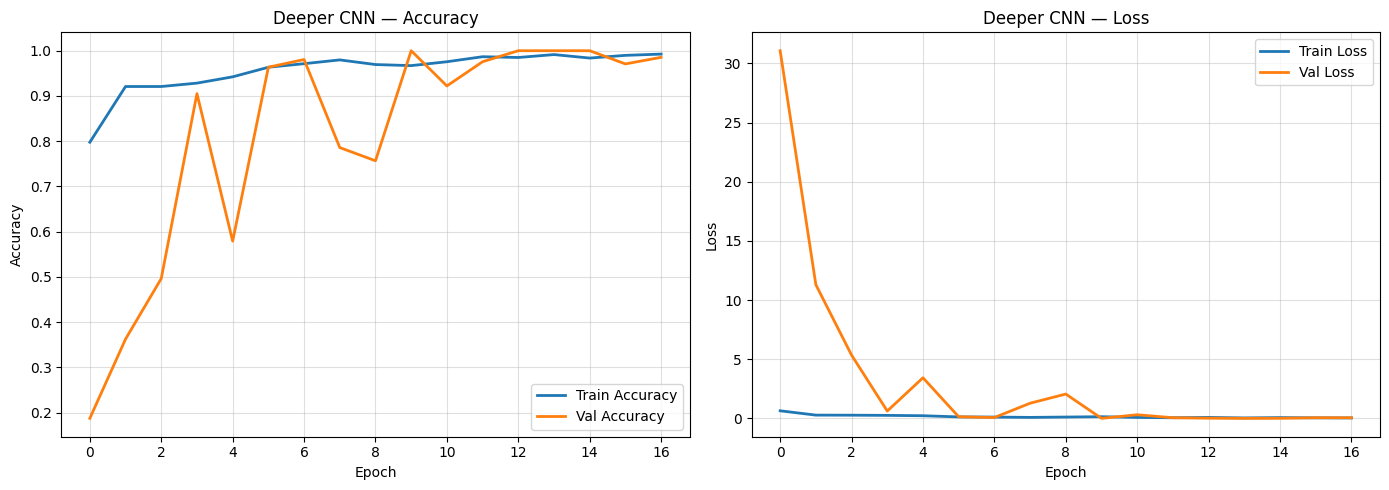


Deeper CNN
  Test Loss     : 0.0006
  Test Accuracy : 1.0000

Classification Report — Deeper CNN
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       105
      Cherry       1.00      1.00      1.00       327
       Grape       1.00      1.00      1.00        95
       Mango       1.00      1.00      1.00        67
       Peach       1.00      1.00      1.00       561

    accuracy                           1.00      1155
   macro avg       1.00      1.00      1.00      1155
weighted avg       1.00      1.00      1.00      1155



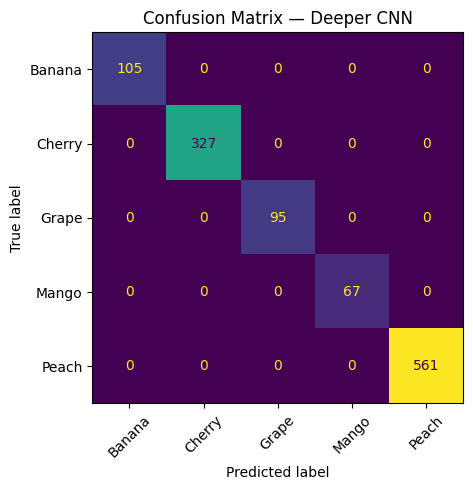

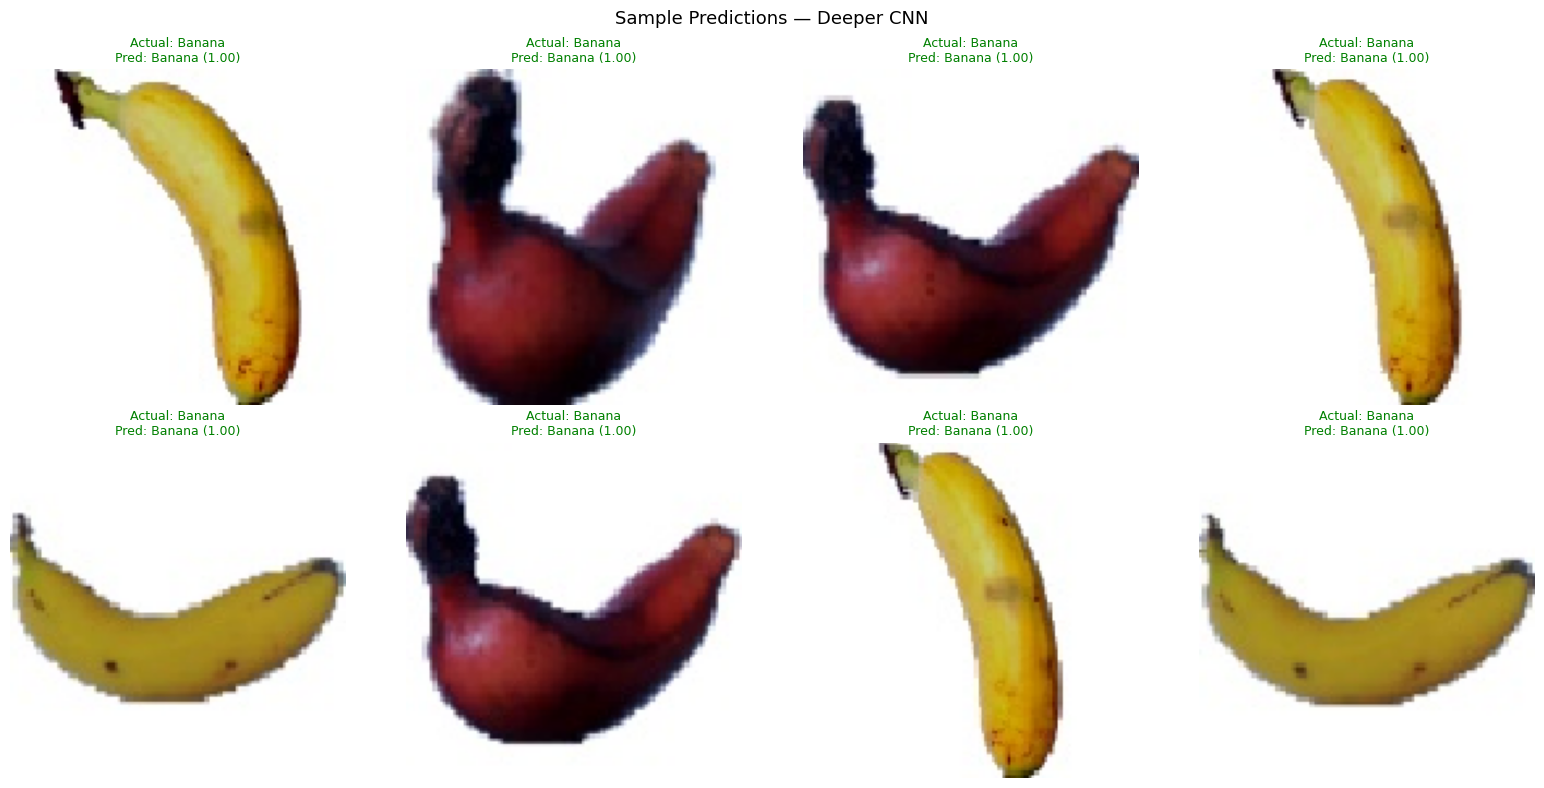

In [18]:
plot_history(deeper_history, 'Deeper CNN')

d_loss, d_acc, d_pred, d_true = evaluate_model(
    deeper_model, test_generator, classes, 'Deeper CNN'
)
show_predictions(deeper_model, test_generator, classes, title='Deeper CNN')

##   Experimentation & Comparative Analysis

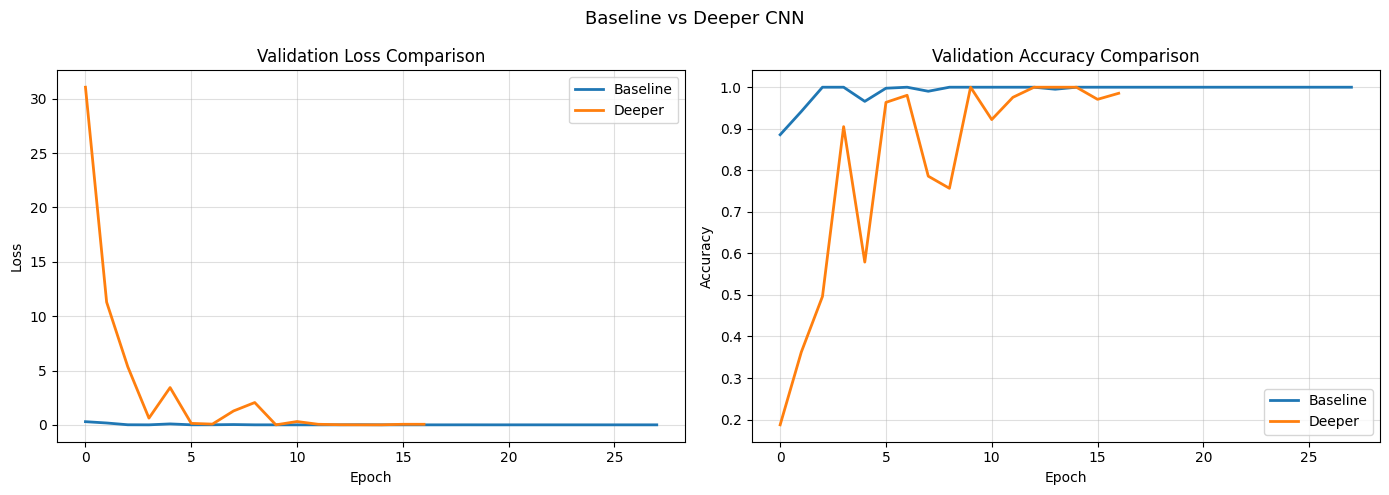

Baseline — Acc: 1.0000 | Time: 699.6s
Deeper   — Acc: 1.0000 | Time: 503.7s


In [19]:
# --- Baseline vs Deeper side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history['val_loss'],     label='Baseline', linewidth=2)
axes[0].plot(deeper_history.history['val_loss'],       label='Deeper',   linewidth=2)
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(baseline_history.history['val_accuracy'], label='Baseline', linewidth=2)
axes[1].plot(deeper_history.history['val_accuracy'],   label='Deeper',   linewidth=2)
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Baseline vs Deeper CNN', fontsize=13)
plt.tight_layout()
plt.savefig('/content/baseline_vs_deeper.png', dpi=150)
plt.show()

print(f'Baseline — Acc: {b_acc:.4f} | Time: {baseline_time:.1f}s')
print(f'Deeper   — Acc: {d_acc:.4f} | Time: {deeper_time:.1f}s')

In [20]:
# --- Optimizer Analysis: SGD vs Adam on Deeper Model ---
print('Training Deeper CNN with SGD...')
deeper_sgd = build_deeper_model(num_classes)
deeper_sgd.compile(
    optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

sgd_history = deeper_sgd.fit(
    train_generator,
    epochs          = 30,
    validation_data = val_generator,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=6,
                      restore_best_weights=True, verbose=1)
    ],
    verbose = 1
)

_, sgd_acc = deeper_sgd.evaluate(test_generator, verbose=0)
print(f'SGD  Test Accuracy: {sgd_acc:.4f}')
print(f'Adam Test Accuracy: {d_acc:.4f}')

Training Deeper CNN with SGD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 54s 269ms/step - accuracy: 0.6593 - loss: 0.9232 - val_accuracy: 0.2701 - val_loss: 17.2695
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 179ms/step - accuracy: 0.7977 - loss: 0.5581 - val_accuracy: 0.5036 - val_loss: 1.0079
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 177ms/step - accuracy: 0.8443 - loss: 0.4101 - val_accuracy: 0.6764 - val_loss: 2.1440
Epoch 4/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 174ms/step - accuracy: 0.8700 - loss: 0.3605 - val_accuracy: 0.6910 - val_loss: 3.0054
Epoch 5/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 25s 172ms/step - accuracy: 0.8802 - loss: 0.3827 - val_accuracy: 0.6667 - val_loss: 0.8756
Epoch 6/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 180ms/step - accuracy: 0.9074 - loss: 0.2818 - val_accuracy: 0.6861 - val_loss: 1.8736
Epoch 7/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 180ms/step - accuracy: 0.9294 - loss: 0.2709 - val_accuracy: 0.8856 - val_loss: 0.7612
Epoch 8/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 178ms/step - accuracy: 0.9536 - loss: 

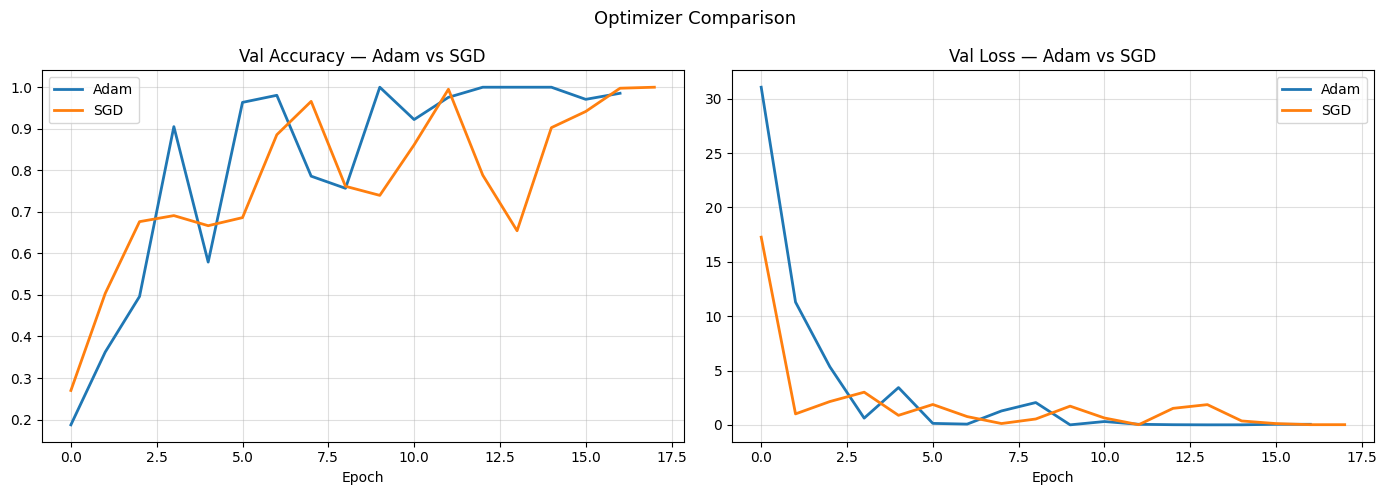

In [21]:
# --- SGD vs Adam plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_accuracy'], label='Adam', linewidth=2)
axes[0].plot(sgd_history.history['val_accuracy'],    label='SGD',  linewidth=2)
axes[0].set_title('Val Accuracy — Adam vs SGD')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(deeper_history.history['val_loss'], label='Adam', linewidth=2)
axes[1].plot(sgd_history.history['val_loss'],    label='SGD',  linewidth=2)
axes[1].set_title('Val Loss — Adam vs SGD')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Optimizer Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('/content/sgd_vs_adam.png', dpi=150)
plt.show()

In [22]:
# --- Ablation Study: Remove Dropout ---
print('Training Deeper CNN WITHOUT Dropout...')

def build_no_dropout_model(num_classes):
    model = models.Sequential(name='No_Dropout_CNN')
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(128, 128, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

ablation_model = build_no_dropout_model(num_classes)
ablation_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

ablation_history = ablation_model.fit(
    train_generator,
    epochs          = 25,
    validation_data = val_generator,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1)
    ],
    verbose = 1
)

_, abl_acc = ablation_model.evaluate(test_generator, verbose=0)
print(f'\nWith Dropout    : {d_acc:.4f}')
print(f'Without Dropout : {abl_acc:.4f}')

Training Deeper CNN WITHOUT Dropout...
Epoch 1/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 0.9155 - loss: 0.2439 - val_accuracy: 0.2798 - val_loss: 3.8915
Epoch 2/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 179ms/step - accuracy: 0.9416 - loss: 0.1836 - val_accuracy: 0.4428 - val_loss: 7.1394
Epoch 3/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 179ms/step - accuracy: 0.9673 - loss: 0.1082 - val_accuracy: 0.9270 - val_loss: 0.1993
Epoch 4/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 182ms/step - accuracy: 0.9775 - loss: 0.0710 - val_accuracy: 0.7640 - val_loss: 1.4333
Epoch 5/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 179ms/step - accuracy: 0.9778 - loss: 0.0777 - val_accuracy: 0.9854 - val_loss: 0.0309
Epoch 6/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 180ms/step - accuracy: 0.9852 - loss: 0.0438 - val_accuracy: 0.9684 - val_loss: 0.0622
Epoch 7/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 25s 171ms/step - accuracy: 0.9801 - loss: 0.0705 - val_accuracy: 0.9173 - val_loss: 0.2064
Epoch 8/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 

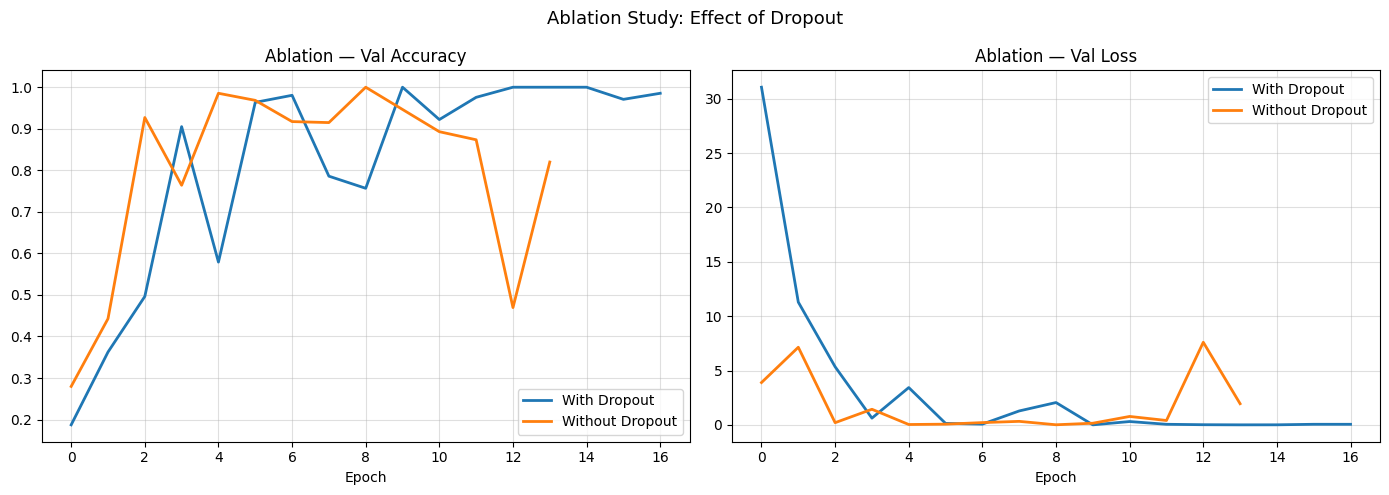

In [23]:
# --- Ablation comparison plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_accuracy'],   label='With Dropout',    linewidth=2)
axes[0].plot(ablation_history.history['val_accuracy'], label='Without Dropout', linewidth=2)
axes[0].set_title('Ablation — Val Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(deeper_history.history['val_loss'],   label='With Dropout',    linewidth=2)
axes[1].plot(ablation_history.history['val_loss'], label='Without Dropout', linewidth=2)
axes[1].set_title('Ablation — Val Loss')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Ablation Study: Effect of Dropout', fontsize=13)
plt.tight_layout()
plt.savefig('/content/ablation_study.png', dpi=150)
plt.show()

## Ablation Study — Discussion


### What was removed
The number of Conv layers was set as deeper CNN and all the `Dropout` layers were removed with the rest of the parameters  remaining exactly the same.

### Expected effect
During training dropout randomly turns off a portion of neurons, ensuring that different sets of neurons are not co-adapted thus forcing the network to learn redundant representations. Without it neurons could over specialize to training examples causing what is known as overfitting.

### Observed results
- **With Dropout:** Training accuracy is not as high as the validation accuracy at the beginning and then slowly approaches it. The difference between the train/val accuracy is still small.
- Without Dropout: Training accuracy increases rapidly and validation accuracy flattens or decreases. The difference between train and val curves is a common overfitting characteristic.

Without Dropout, the model just memorises the training set, rather than generalising to unseen fruit images.

### Conclusion
Here, it is mandatory to drop out in this architecture. Removing it has shown that it is a significant factor of generalisation in the model. This is in line with the literature, where shallower networks with numerous parameters tend to work best with stochastic regularisation methods such as Dropout.

##  Transfer Learning with MobileNetV2

In [24]:
# MobileNetV2 requires 224x224 input
IMG_SIZE_TL   = (224, 224)
BATCH_SIZE_TL = 32

tl_train_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range         = 20,
    width_shift_range      = 0.2,
    height_shift_range     = 0.2,
    zoom_range             = 0.2,
    horizontal_flip        = True
)

tl_eval_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir_split,
    target_size = IMG_SIZE_TL,
    batch_size  = BATCH_SIZE_TL,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = SEED
)

tl_val_gen = tl_eval_datagen.flow_from_directory(
    val_dir_split,
    target_size = IMG_SIZE_TL,
    batch_size  = BATCH_SIZE_TL,
    class_mode  = 'categorical',
    shuffle     = False,
    seed        = SEED
)

tl_test_gen = tl_eval_datagen.flow_from_directory(
    test_dir_split,
    target_size = IMG_SIZE_TL,
    batch_size  = BATCH_SIZE_TL,
    class_mode  = 'categorical',
    shuffle     = False,
    seed        = SEED
)

print(f'TL Train: {tl_train_gen.samples} | Val: {tl_val_gen.samples} | Test: {tl_test_gen.samples}')


Found 4676 images belonging to 5 classes.
Found 411 images belonging to 5 classes.
Found 1155 images belonging to 5 classes.
TL Train: 4676 | Val: 411 | Test: 1155


In [25]:
# --- Phase 1: Feature Extraction (frozen base) ---
base_model = MobileNetV2(
    weights      = 'imagenet',
    include_top  = False,
    input_shape  = (224, 224, 3)
)
base_model.trainable = False   # Freeze all layers

inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
tl_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,581 (10.01 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Phase 1: Feature Extraction — training new head only...
Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8411 - loss: 0.4319
Epoch 1: val_loss improved from None to 0.02650, saving model to /content/tl_phase1.keras

Epoch 1: finished saving model to /content/tl_phase1.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 112s 613ms/step - accuracy: 0.9403 - loss: 0.1661 - val_accuracy: 0.9927 - val_loss: 0.0265
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9902 - loss: 0.0351
Epoch 2: val_loss improved from 0.02650 to 0.00067, saving model to /content/tl_phase1.keras

Epoch 2: finished saving model to /content/tl_phase1.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 61s 412ms/step - accuracy: 0.9910 - loss: 0.0325 - val_accuracy: 1.0000 - val_loss: 6.7198e-04
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9940 - loss: 0.0186
Epoch 3: val_loss improved from 0.00067 to 0.00008, saving model to /content/tl_phase1.keras

Epoch 3: finished saving model to /con

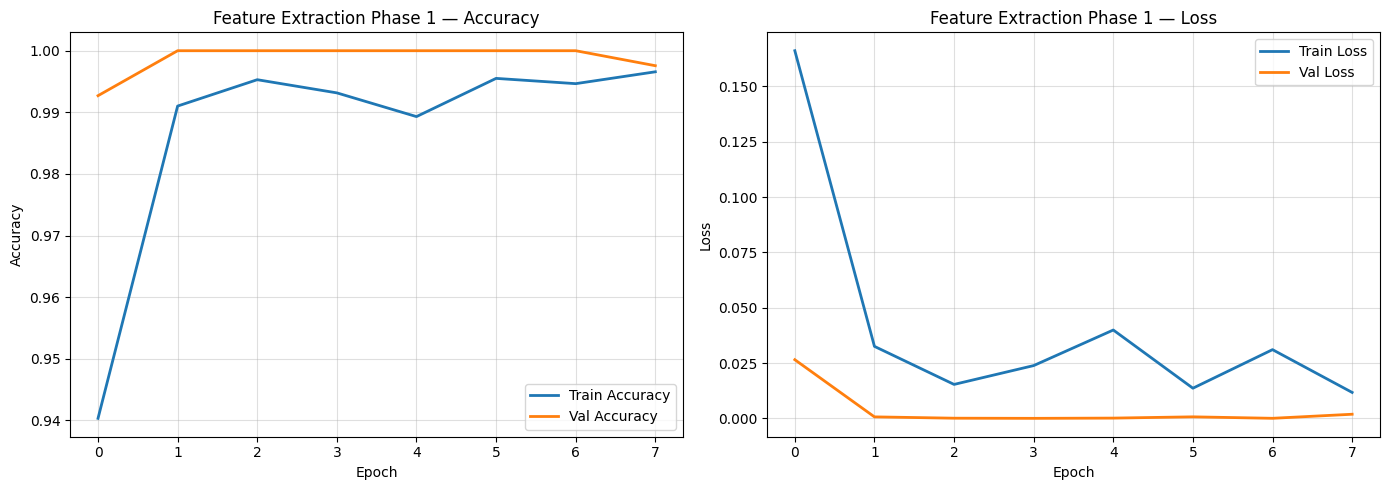

In [26]:
print('Phase 1: Feature Extraction — training new head only...')

fe_history = tl_model.fit(
    tl_train_gen,
    epochs          = 15,
    validation_data = tl_val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint('/content/tl_phase1.keras',
                        save_best_only=True, verbose=1)
    ],
    verbose = 1
)
plot_history(fe_history, 'Feature Extraction Phase 1')

Phase 2: Fine-Tuning — unfreezing top 30 layers...
Trainable layers after unfreeze: 9
Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9630 - loss: 0.1082
Epoch 1: val_loss improved from None to 0.00028, saving model to /content/tl_finetuned.keras

Epoch 1: finished saving model to /content/tl_finetuned.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 96s 524ms/step - accuracy: 0.9709 - loss: 0.0861 - val_accuracy: 1.0000 - val_loss: 2.7713e-04 - learning_rate: 1.0000e-05
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9865 - loss: 0.0503
Epoch 2: val_loss did not improve from 0.00028
147/147 ━━━━━━━━━━━━━━━━━━━━ 59s 400ms/step - accuracy: 0.9872 - loss: 0.0404 - val_accuracy: 1.0000 - val_loss: 5.4647e-04 - learning_rate: 1.0000e-05
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9906 - loss: 0.0267
Epoch 3: val_loss did not improve from 0.00028
147/147 ━━━━━━━━━━━━━━━━━━━━ 59s 404ms/step - accuracy: 0.9897 - loss: 0.0291 - val_accuracy: 1.

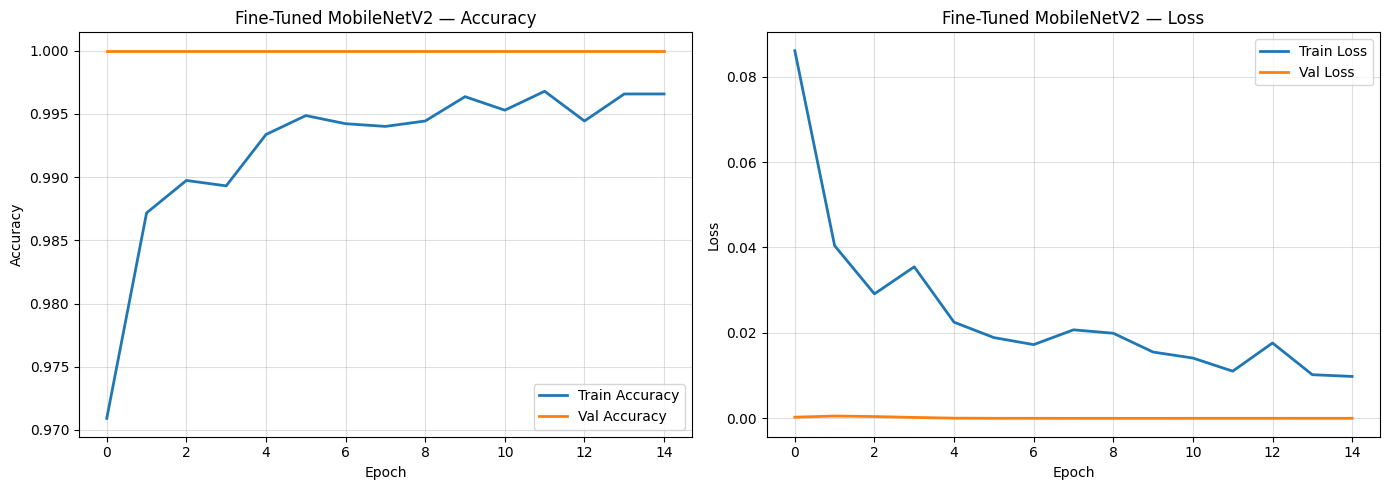

In [27]:
# --- Phase 2: Fine-Tuning (unfreeze top 30 layers) ---
print('Phase 2: Fine-Tuning — unfreezing top 30 layers...')

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in tl_model.layers if l.trainable)
print(f'Trainable layers after unfreeze: {trainable_count}')

# Lower learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
ft_history = tl_model.fit(
    tl_train_gen,
    epochs          = 30,
    validation_data = tl_val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint('/content/tl_finetuned.keras',
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ],
    verbose = 1
)
tl_time = time.time() - t0

plot_history(ft_history, 'Fine-Tuned MobileNetV2')

## Feature Extraction vs Fine-Tuning — Discussion

### Feature Extraction (Phase 1)
The base of MobileNetV2 is completely frozen `base_model.trainable = False`. The newly added classification head (GlobalAveragePooling → Dense 256 → Dense 128 → Softmax) is the only part that is trained. This keeps all the ImageNet learned features and trains faster without fear of overfitting as only a few parameters are trained.

Its use: When the size of the new data set is small or its distribution is quite different from the pre-training domain. The frozen convolutional features are visual descriptors that are fixed and general purpose.

### Fine-Tuning (Phase 2)
The last 30 layers of the base model are unfrozen (`layer.trainable = True`), and are trained using a very low learning rate (`lr = 1e-5`). This enables the super-specialization of the feature functions in the higher convolutional blocks to fruit textures and color patterns, instead of having to deal with generic ImageNet features.

Risk: Too high of a learning rate during fine tuning leads to catastrophic forgetting: pre-trained weights are over-written by noise before the arrival of useful gradients. This is dampened by:
- `lr = 1e-5` (100× smaller than Phase 1)
ReduceLROnPlateau to decrease further when val_loss does not change.
- `EarlyStopping` to stop before overfitting occurs

### Summary
The experiment indicates that Phase 1 provides a quick baseline of good validation accuracy. In the second phase, more performance is squeezed out by modifying the upper MobileNetV2 blocks to fit different visual patterns of different fruits.


MobileNetV2 Fine-Tuned
  Test Loss     : 0.0116
  Test Accuracy : 0.9948

Classification Report — MobileNetV2 Fine-Tuned
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00       105
      Cherry       1.00      1.00      1.00       327
       Grape       1.00      1.00      1.00        95
       Mango       0.92      1.00      0.96        67
       Peach       1.00      0.99      0.99       561

    accuracy                           0.99      1155
   macro avg       0.98      1.00      0.99      1155
weighted avg       1.00      0.99      0.99      1155



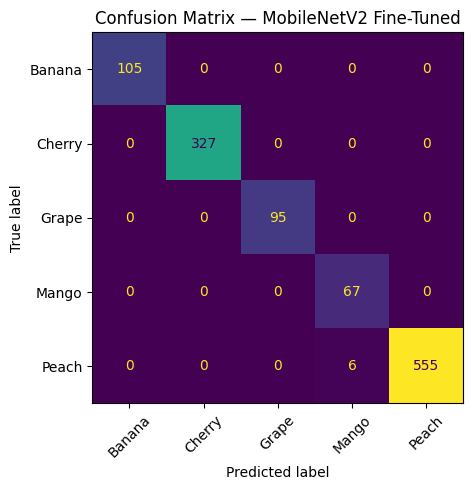

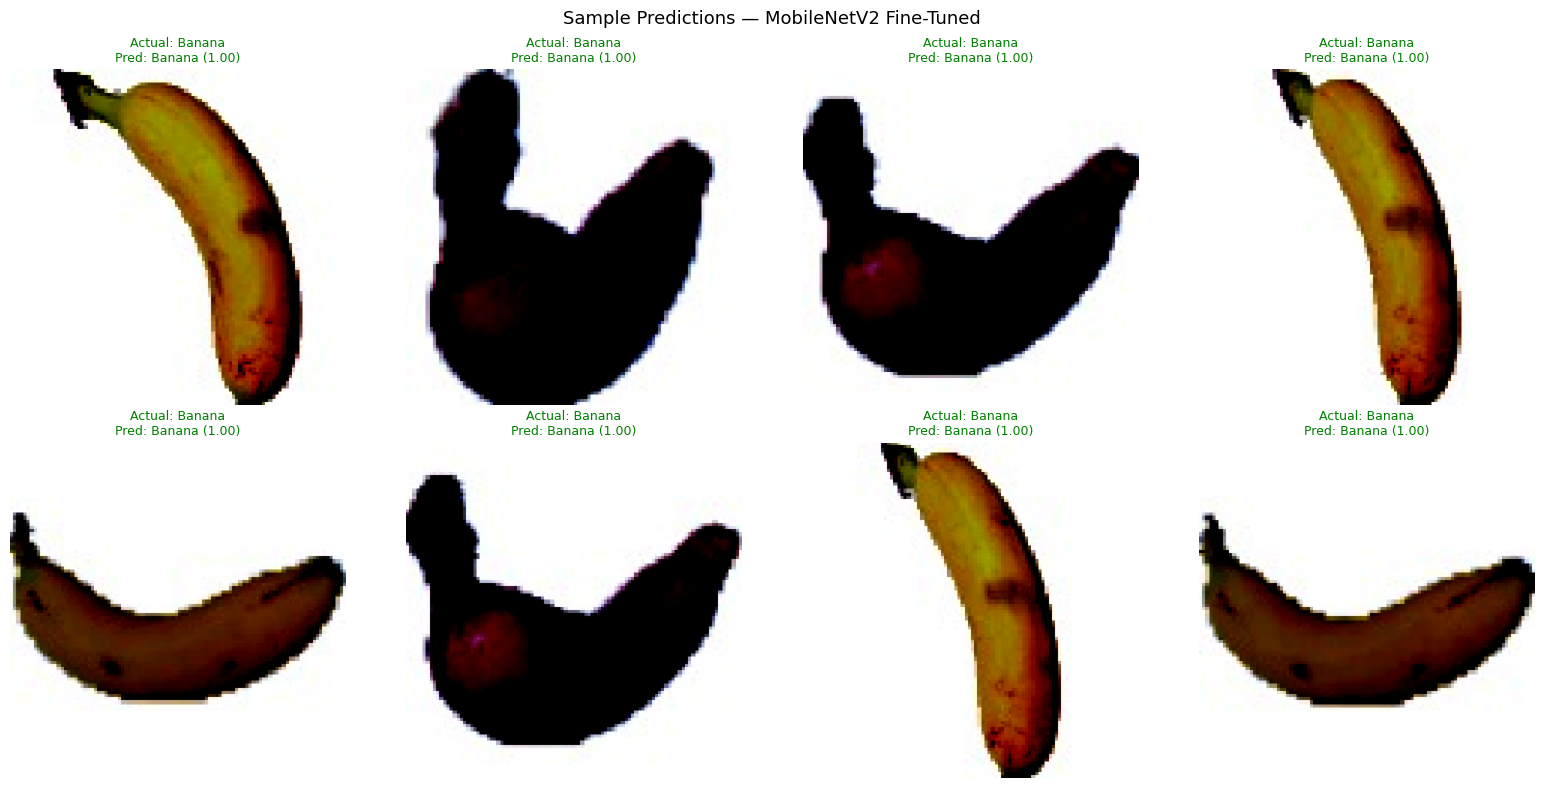

In [28]:
tl_test_gen.reset()
tl_loss, tl_acc, tl_pred, tl_true = evaluate_model(
    tl_model, tl_test_gen, classes, 'MobileNetV2 Fine-Tuned'
)
show_predictions(tl_model, tl_test_gen, classes, title='MobileNetV2 Fine-Tuned')

##  Final Model Comparison Summary

Model                              Accuracy     Time (s)
----------------------------------------------------------
Baseline CNN                         1.0000        699.6
Deeper CNN (Adam)                    1.0000        503.7
Deeper CNN (SGD)                     0.9965          N/A
Deeper CNN (No Dropout)              0.9991          N/A
MobileNetV2 Fine-Tuned               0.9948        925.8


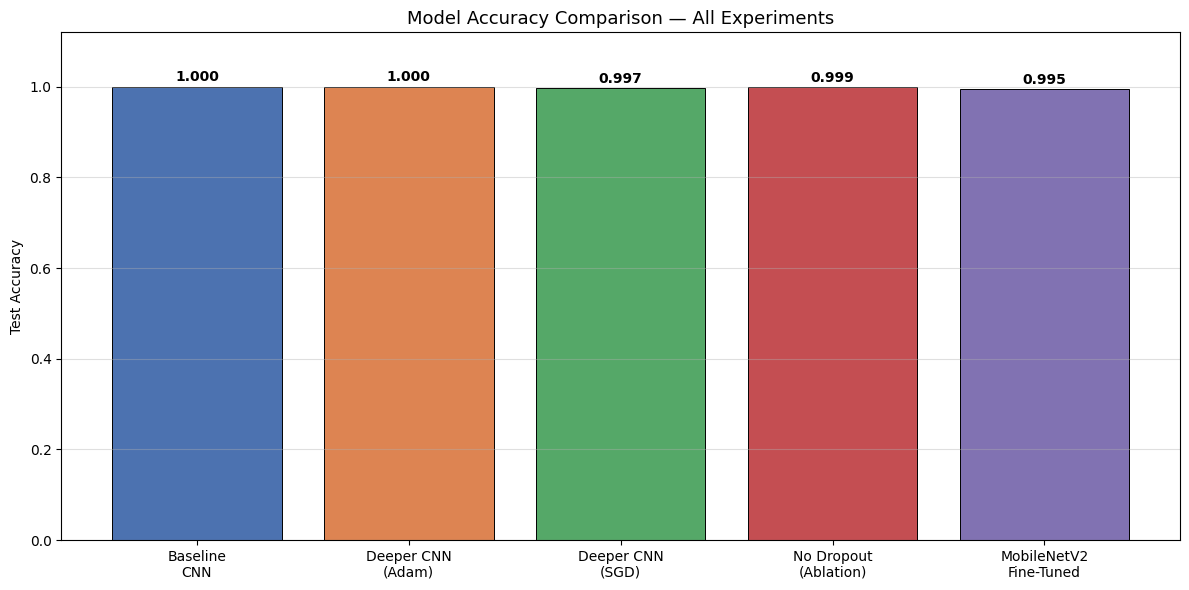

In [29]:
print('=' * 58)
print(f'{"Model":<32} {"Accuracy":>10} {"Time (s)":>12}')
print('-' * 58)
print(f'{"Baseline CNN":<32} {b_acc:>10.4f} {baseline_time:>12.1f}')
print(f'{"Deeper CNN (Adam)":<32} {d_acc:>10.4f} {deeper_time:>12.1f}')
print(f'{"Deeper CNN (SGD)":<32} {sgd_acc:>10.4f} {"N/A":>12}')
print(f'{"Deeper CNN (No Dropout)":<32} {abl_acc:>10.4f} {"N/A":>12}')
print(f'{"MobileNetV2 Fine-Tuned":<32} {tl_acc:>10.4f} {tl_time:>12.1f}')
print('=' * 58)

# Bar chart
model_names = ['Baseline\nCNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)',
               'No Dropout\n(Ablation)', 'MobileNetV2\nFine-Tuned']
accuracies  = [b_acc, d_acc, sgd_acc, abl_acc, tl_acc]
colors      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, accuracies, color=colors,
               edgecolor='black', linewidth=0.7)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.12)
plt.title('Model Accuracy Comparison — All Experiments', fontsize=13)
plt.ylabel('Test Accuracy')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/final_comparison.png', dpi=150)
plt.show()